In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as tvt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)



device: cuda


In [2]:
import albumentations as A

BASE = "/kaggle/input/aerial-cactus-identification"
TRAIN_CSV = os.path.join(BASE, "train.csv")
SAMPLE_SUB = os.path.join(BASE, "sample_submission.csv")
TRAIN_DIR = os.path.join(BASE, "train")
TEST_DIR = os.path.join(BASE, "test")

assert os.path.exists(TRAIN_CSV), f"Missing: {TRAIN_CSV}"
assert os.path.exists(SAMPLE_SUB), f"Missing: {SAMPLE_SUB}"
assert os.path.isdir(TRAIN_DIR), f"Missing: {TRAIN_DIR}"
assert os.path.isdir(TEST_DIR), f"Missing: {TEST_DIR}"



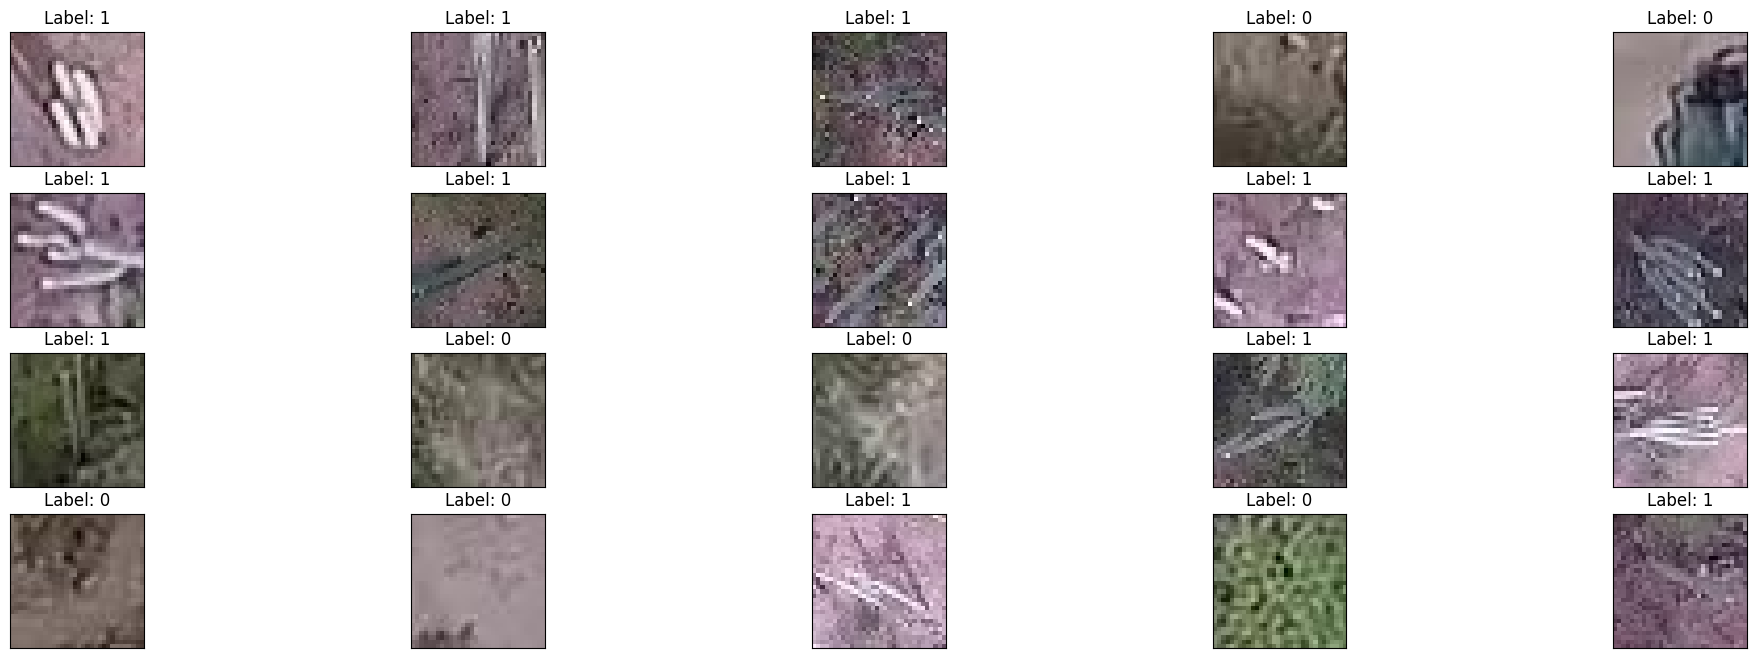

In [3]:
labels = pd.read_csv(TRAIN_CSV)


# BUGFIX: Kaggle dataset contains nested folders like test/test and train/train in some mirrors.
# When listing files, filter to actual image files only to avoid trying to read directories.
def list_image_files(folder, exts=(".jpg", ".jpeg", ".png")):
    out = []
    for fn in os.listdir(folder):
        p = os.path.join(folder, fn)
        if os.path.isfile(p) and fn.lower().endswith(exts):
            out.append(fn)
    return out


try:
    fig = plt.figure(figsize=(25, 8))
    train_imgs = list_image_files(TRAIN_DIR)
    for idx, img in enumerate(np.random.choice(train_imgs, 20, replace=False)):
        ax = fig.add_subplot(4, 20 // 4, idx + 1, xticks=[], yticks=[])
        im = Image.open(os.path.join(TRAIN_DIR, img))
        plt.imshow(im)
        lab = labels.loc[labels["id"] == img, "has_cactus"].values[0]
        ax.set_title(f"Label: {lab}")
    plt.show()
except Exception as e:
    print("Plotting skipped:", repr(e))



In [4]:
# BUGFIX: filter to image files only (avoid nested 'test' directory entry).
test_img = sorted(list_image_files(TEST_DIR))
test_df = pd.DataFrame(test_img, columns=["id"])
test_df["has_cactus"] = -1
test_df["data_type"] = "test"

labels["has_cactus"] = labels["has_cactus"].astype(int)
labels["data_type"] = "train"

labels.head()



,id,has_cactus,data_type
0,2de8f189f1dce439766637e75df0ee27.jpg,1,train
1,36704d250f236238e7f996812c48235d.jpg,1,train
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1,train
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1,train
4,152491e0daf75c0e669400300ff7e645.jpg,1,train


In [5]:
labels.loc[labels["data_type"] == "train", "has_cactus"].value_counts()



has_cactus
1    10628
0     3547
Name: count, dtype: int64

In [6]:
train, valid = train_test_split(
    labels, stratify=labels.has_cactus, test_size=0.2, random_state=SEED
)
train = train.reset_index(drop=True)
valid = valid.reset_index(drop=True)




In [7]:
def reader_fn(i, row):
    if row["data_type"] == "train":
        p = os.path.join(TRAIN_DIR, row["id"])
    else:
        p = os.path.join(TEST_DIR, row["id"])
    image = cv2.imread(p)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {p}")
    image = image[:, :, ::-1]  # BGR -> RGB
    label = torch.tensor([float(row["has_cactus"])], dtype=torch.float32)
    return {"image": image, "label": label}




In [8]:
def augs(p=0.5):
    return A.Compose(
        [
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.5),
        ],
        p=p,
    )




In [9]:
class Transformer:
    def __init__(self, key, fn):
        self.key = key
        self.fn = fn

    def __call__(self, sample):
        sample[self.key] = self.fn(sample[self.key])
        return sample


def to_torch():
    def _fn(x):
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x.transpose(2, 0, 1)).float().div(255.0)
        elif torch.is_tensor(x):
            x = x.float()
        else:
            raise TypeError(f"Unsupported type for to_torch: {type(x)}")
        return x

    return _fn


def normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)

    def _fn(x):
        return (x - mean_t.to(x.device)) / std_t.to(x.device)

    return _fn


class Compose:
    def __init__(self, tfms):
        self.tfms = tfms

    def __call__(self, sample):
        for t in self.tfms:
            sample = t(sample)
        return sample


def get_transforms(dataset_key, size, p):
    PRE_TFMS = Transformer(
        dataset_key, lambda x: cv2.resize(x, (size, size), interpolation=cv2.INTER_AREA)
    )
    AUGS = Transformer(dataset_key, lambda x: augs(p=p)(image=x)["image"])
    NRM_TFMS = Compose(
        [
            Transformer(dataset_key, to_torch()),
            Transformer(dataset_key, normalize()),
        ]
    )

    train_tfms = Compose([PRE_TFMS, AUGS, NRM_TFMS])
    val_tfms = Compose([PRE_TFMS, NRM_TFMS])
    return train_tfms, val_tfms




In [10]:
train_tfms, val_tfms = get_transforms("image", 32, 0.5)




In [11]:
class DataKek(Dataset):
    def __init__(self, df, reader_fn, transforms=None):
        self.df = df.reset_index(drop=True)
        self.reader_fn = reader_fn
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i].to_dict()
        sample = self.reader_fn(i, row)
        if self.transforms is not None:
            sample = self.transforms(sample)
        if not torch.is_tensor(sample["label"]):
            sample["label"] = torch.tensor(sample["label"], dtype=torch.float32)
        return sample


def collate_dict(batch):
    images = torch.stack([b["image"] for b in batch], dim=0)
    labels = torch.stack([b["label"] for b in batch], dim=0)
    return {"image": images, "label": labels}


train_dk = DataKek(df=train, reader_fn=reader_fn, transforms=train_tfms)
val_dk = DataKek(df=valid, reader_fn=reader_fn, transforms=val_tfms)

batch_size = 64
workers = 0

train_dl = DataLoader(
    train_dk,
    batch_size=batch_size,
    num_workers=workers,
    shuffle=True,
    drop_last=True,
    collate_fn=collate_dict,
)
val_dl = DataLoader(
    val_dk,
    batch_size=batch_size,
    num_workers=workers,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_dict,
)



In [12]:
test_dk = DataKek(df=test_df, reader_fn=reader_fn, transforms=val_tfms)
test_dl = DataLoader(
    test_dk,
    batch_size=batch_size,
    num_workers=workers,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_dict,
)




In [13]:
class Net(nn.Module):
    def __init__(self, num_classes: int, p: float = 0.2):
        super().__init__()
        backbone = torchvision.models.densenet169(
            weights=torchvision.models.DenseNet169_Weights.IMAGENET1K_V1
        )
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(1664),
            nn.Dropout(p),
            nn.Linear(1664, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = F.relu(x, inplace=True)
        x = self.pool(x)
        x = self.head(x)
        return x




In [14]:
model = Net(num_classes=1).to(device)
criterion = nn.BCEWithLogitsLoss()




Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth
100%|██████████| 54.7M/54.7M [00:00<00:00, 110MB/s]


In [15]:
def step_fn(model: torch.nn.Module, batch: dict) -> torch.Tensor:
    inp = batch["image"].to(device)
    return model(inp)




In [16]:
def bce_accuracy(
    target: torch.Tensor, preds: torch.Tensor, thresh: float = 0.5
) -> float:
    target = target.detach().cpu().numpy().reshape(-1)
    preds = (torch.sigmoid(preds).detach().cpu().numpy().reshape(-1) > thresh).astype(
        int
    )
    return accuracy_score(target, preds)


def roc_auc(target: torch.Tensor, preds: torch.Tensor) -> float:
    target = target.detach().cpu().numpy().reshape(-1)
    preds = torch.sigmoid(preds).detach().cpu().numpy().reshape(-1)
    try:
        return roc_auc_score(target, preds)
    except Exception:
        return float("nan")




In [17]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.99)

epochs_stage1 = 5
steps_per_epoch = len(train_dl)
scheduler1 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-2,
    epochs=epochs_stage1,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.3,
    div_factor=25.0,
    final_div_factor=1e4,
)


def run_epoch(train_mode=True, scheduler=None):
    model.train(train_mode)
    total_loss = 0.0
    all_preds = []
    all_targs = []
    dl = train_dl if train_mode else val_dl

    for batch in dl:
        x = batch["image"].to(device)
        y = batch["label"].to(device)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        if train_mode:
            loss.backward()
            optimizer.step()
            if scheduler is not None:
                scheduler.step()

        total_loss += loss.item() * x.size(0)
        all_preds.append(logits.detach().cpu())
        all_targs.append(y.detach().cpu())

    all_preds = torch.cat(all_preds, dim=0)
    all_targs = torch.cat(all_targs, dim=0)
    avg_loss = total_loss / len(dl.dataset)
    acc = bce_accuracy(all_targs, all_preds)
    auc = roc_auc(all_targs, all_preds)
    return avg_loss, acc, auc




In [18]:
t0 = time.time()
for ep in range(1, epochs_stage1 + 1):
    tr_loss, tr_acc, tr_auc = run_epoch(train_mode=True, scheduler=scheduler1)
    va_loss, va_acc, va_auc = run_epoch(train_mode=False, scheduler=None)
    print(
        f"[Stage1][{ep}/{epochs_stage1}] "
        f"train loss {tr_loss:.4f} acc {tr_acc:.4f} auc {tr_auc:.6f} | "
        f"val loss {va_loss:.4f} acc {va_acc:.4f} auc {va_auc:.6f}"
    )
print("Stage1 time:", round(time.time() - t0, 1), "s")



[Stage1][1/5] train loss 0.1297 acc 0.9544 auc 0.991596 | val loss 0.0185 acc 0.9937 auc 0.999749
[Stage1][2/5] train loss 0.0375 acc 0.9862 auc 0.998883 | val loss 0.0116 acc 0.9965 auc 0.999923
[Stage1][3/5] train loss 0.0157 acc 0.9949 auc 0.999783 | val loss 0.0110 acc 0.9958 auc 0.999888
[Stage1][4/5] train loss 0.0112 acc 0.9966 auc 0.999785 | val loss 0.0074 acc 0.9972 auc 0.999965
[Stage1][5/5] train loss 0.0102 acc 0.9966 auc 0.999892 | val loss 0.0056 acc 0.9979 auc 0.999980
Stage1 time: 114.7 s


In [19]:
epochs_stage2 = 5
scheduler2 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=epochs_stage2,
    steps_per_epoch=len(train_dl),
    pct_start=0.2,
    div_factor=25.0,
    final_div_factor=1e4,
)

t0 = time.time()
for ep in range(1, epochs_stage2 + 1):
    tr_loss, tr_acc, tr_auc = run_epoch(train_mode=True, scheduler=scheduler2)
    va_loss, va_acc, va_auc = run_epoch(train_mode=False, scheduler=None)
    print(
        f"[Stage2][{ep}/{epochs_stage2}] "
        f"train loss {tr_loss:.4f} acc {tr_acc:.4f} auc {tr_auc:.6f} | "
        f"val loss {va_loss:.4f} acc {va_acc:.4f} auc {va_auc:.6f}"
    )
print("Stage2 time:", round(time.time() - t0, 1), "s")



[Stage2][1/5] train loss 0.0056 acc 0.9981 auc 0.999980 | val loss 0.0065 acc 0.9968 auc 0.999973
[Stage2][2/5] train loss 0.0065 acc 0.9983 auc 0.999954 | val loss 0.0064 acc 0.9982 auc 0.999969
[Stage2][3/5] train loss 0.0041 acc 0.9987 auc 0.999985 | val loss 0.0060 acc 0.9979 auc 0.999975
[Stage2][4/5] train loss 0.0047 acc 0.9986 auc 0.999980 | val loss 0.0059 acc 0.9982 auc 0.999969
[Stage2][5/5] train loss 0.0040 acc 0.9990 auc 0.999990 | val loss 0.0058 acc 0.9975 auc 0.999975
Stage2 time: 108.8 s


In [20]:
# BUGFIX: inference now works because test_df contains only image files, not nested directories.
model.eval()
pred_list = []
with torch.no_grad():
    for batch in test_dl:
        x = batch["image"].to(device)
        logits = model(x)
        probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
        pred_list.append(probs)

preds = np.concatenate(pred_list, axis=0)
print("preds shape:", preds.shape, "min/max:", float(preds.min()), float(preds.max()))



preds shape: (3325,) min/max: 0.0 0.9999997615814209


In [21]:
# Ensure submission ordering matches sample_submission.csv (safer than relying on directory order)
sub = pd.read_csv(SAMPLE_SUB)

# BUGFIX: build mapping from ids to predictions and fill any missing ids with mean prediction.
pred_map = dict(zip(test_df["id"].values, preds))
sub["has_cactus"] = sub["id"].map(pred_map).astype(float)

if sub["has_cactus"].isna().any():
    sub["has_cactus"] = sub["has_cactus"].fillna(float(np.mean(preds)))

# Keep file name with .csv suffix as required
sub.to_csv("sub.csv", index=False)
sub.head()



,id,has_cactus
0,09034a34de0e2015a8a28dfe18f423f6.jpg,0.999989
1,134f04305c795d6d202502c2ce3578f3.jpg,0.999969
2,41fad8d145e6c41868ce3617e30a2545.jpg,0.999892
3,35f8a11352c8d41b6231bb33d8d09f7e.jpg,0.999882
4,b77dc902b035887cbbc01920ce0e3151.jpg,0.999967


In [22]:
assert os.path.exists("sub.csv"), "sub.csv was not created"
check = pd.read_csv("sub.csv")
assert list(check.columns) == ["id", "has_cactus"], f"Wrong columns: {check.columns}"
assert len(check) == len(
    pd.read_csv(SAMPLE_SUB)
), "Row count mismatch vs sample_submission"
assert (
    check["has_cactus"].between(0, 1).all()
), "Predictions must be probabilities in [0,1]"
print("Submission ready:", check.shape)

Submission ready: (3325, 2)
